# FDSFE Midterm Instructions

### Due Date: 11:59pm Friday October 4th, 2025

To submit, share this notebook to <fortino@udel.edu> and give edit permissions.

### Resources

This exam is entirely open book, open note, and open internet. You may use any resource to help you on this exam *except* for other people or generative AI.

### Getting Started

In order to start working on this midterm you must go to `File` -> `Save a copy in Drive`. Then, you can edit and rename the new copy of this notebook which you will submit.

### Naming Conventions
Your submission notebook must follow specific name conventions:

* The name of first assignment file is `FDSFE_F25_Midterm.ipynb`.
* When you make a copy of it, the new file will be named `Copy of FDSFE_F25_Midterm.ipynb`.
* You will rename this file in the following fashion:
    * First you will include the first letter of your first name, capitalized
    * Next you will include your surname, also capitalized.
    * Finally you will include an underscore followed by the original name of the assignment.

For example: My first name is Willow and my last name is Fortino, so I would rename the first assignment as `WFORTINO_FDSFE_F25_Midterm.ipynb`.

# AI Use and Collaboration Statement

You are not allowed to use generative AI or large language models like chatGPT or Google Gemini on this midterm. If you do, you will receive a 0 on this midterm.

You are not allowed to work with others on this midterm. If you do, you will receive a 0 on this midterm.

### Signature

Write your name here to affirm that you have read the AI Use and Collaboration statement.

[YOUR NAME HERE]

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Part 1: NHRT (50 points total)

## Introduction
You are a high school math teacher and you want to determine if your students in 2016 performed better on their first exam than the students in 2015 did. If they did perform better, then perhaps you are becoming a better teacher!

You have two samples of high school student test results. The first sample, stored in the variable `sample_1`, contains 100 test results from 2015. The second sample, stored in the variable `sample_2`, contains 100 test results from 2016.

## Objective
Use the [Student's t-test](https://en.wikipedia.org/wiki/Student%27s_t-test) implemented with the SciPy function [`ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) to determine if one sample has a larger mean than the other sample.

## Tasks

1. (10 points) **Data Exploration and Visualization**
    - In the cell below, complete the function `plot_samples` with your own code.
    - In one figure, plot the following:
        - A histogram of `sample_1`.
        - A histogram of `sample_2`.
    - Each histogram must have a descriptive label. The figure must have a legend in a location that does not obscure the plotted data.
    - Each histogram must not obscure the other histogram (see the keyword argument `histtype` in the matplotlib `hist` function).
    - The figure must have appropriate x-axis and y-axis labels. Units must be indicated, where relevant.
    - The figure must be an appropriate size so that all elements of the figure are clearly visible.

2. (10 points) **Figure Caption**
    - In the text cell below titled "Figure Caption", write a caption for your figure.
    - Explain what is being plotted.
    - Explain why the figure is important.

3. (10 points) **NHRT**
    - In the cell below titled "Confidence Interval" specify your confidence interval.
    - In the cell below titled "Null Hypothesis" write down the Null Hypothesis of this two sample t-test. (**Hint**: the documentation for the SciPy function [`ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) may help.)
    - In the cell below titled "Alternative Hypothesis" write down the Alternative Hypothesis of this two sample t-test.

4. (10 points) **Perform the test**
    - In the cell below, complete the function `perform_test` with your own code.
    - Using the SciPy function [`ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html), determine the p-value for the test. (**Hint**: Be sure to read the introduction thoroughly in order to determine what kind of test you are doing.)

5. (10 points) **Conclusion**
    - In the cell below, explain whether or not you can reject the null hypothesis on the basis of the test.

In [ ]:
"""Do not change anything in this cell."""

sample_1 = np.array([
    92, 100,  79,  79,  92,  76, 100,  91,  83,  83,  74, 100,  67,
    89,  81,  83,  91,  82,  83,  94,  75,  68,  77,  81,  99, 100,
    100,  76,  86,  83,  67,  92,  79,  79,  62,  90,  79,  91,  88,
    100,  73, 100,  82,  88,  82,  86,  92,  96,  83,  96,  84,  82,
    84,  76,  74,  88,  73,  74, 100, 100,  81,  90,  85,  96,  92,
    76,  80,  76,  81,  82,  80, 100,  71,  86,  89, 100,  85,  79,
    93,  91,  91, 100,  82,  73, 100,  77,  76,  71,  77,  83, 100,
    92,  91,  91,  97,  75,  88,  89,  85,  93
    ])

sample_2 = np.array([
    100,  87,  97, 100,  74,  87,  96,  82,  81,  74,  88, 100,  80,
    81,  63,  88,  98,  67, 100,  89,  75,  92,  85,  77,  82,  93,
    92,  80,  96,  82,  91,  81,  85,  70,  96,  79,  72,  85,  87,
    92,  87,  93,  84,  95,  82,  75, 100, 100, 100,  91,  91,  94,
    95,  87,  92,  87,  88,  87,  86,  95, 100, 100,  98,  81,  95,
    100,  86,  81,  76,  90,  80,  87,  97,  71,  93,  90,  85, 100,
    99,  74, 100,  85,  81,  82,  92,  92, 100, 100,  93,  72,  84,
    89,  78,  98,  96,  81, 100,  96,  78,  94
    ])

### Task 1: Data Exploration and Visualization

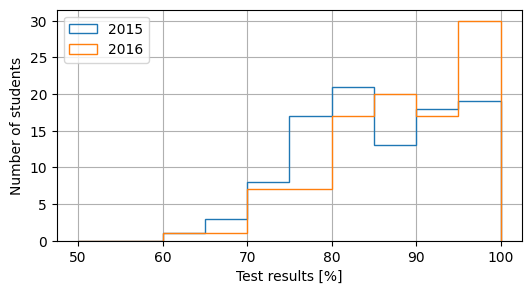

In [ ]:
def plot_samples(sample_1, sample_2):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(sample_1, bins=10, range=(50, 100), histtype="step", label="2015")
    ax.hist(sample_2, bins=10, range=(50, 100), histtype="step", label="2016")
    ax.grid()
    ax.legend(loc="upper left")
    ax.set_xlabel("Test results [%]")
    ax.set_ylabel("Number of students")
    fig.show()
    return None

plot_samples(sample_1, sample_2)

### Task 2: Figure Caption

[WRITE YOUR FIGURE CAPTION HERE]

### Task 3a: Confidence Interval

[DECLARE YOUR CONFIDENCE INTERVAL HERE]

### Task 3b: Null Hypothesis

[WRITE THE NULL HYPOTHESIS OF THIS TEST HERE]

### Task 3c: Alternative Hypothesis

[WRITE THE ALTERNATIVE HYPOTHESIS OF THIS TEST HERE]

### Task 4: Perform the test

In [ ]:
def perform_test(sample_1, sample_2):
    pvalue = stats.ttest_ind(sample_1, sample_2, alternative="less").pvalue
    return pvalue

pvalue = perform_test(sample_1, sample_2)
print(f"The p-value for this test is: {pvalue:.5f}")

The p-value for this test is: 0.02376


### Task 5: Conclusion

[DECLARE WHETHER YOU CAN REJECT THE NULL HYPOTHESIS OR NOT HERE]

# Part 2: Linear Regression (50 points total)

## Introduction

[This dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) contains ten features that are used to predict diabetes disease progression after one year.

You have been given `df`, a Pandas DataFrame that includes 11 columns and 442 rows. The column named `"Target"` is a measure of disease progression; this is the quantity you are regressing. The other ten columns are your features.

## Objective

You will use these ten features to train a linear regression model to predict `Target`.

## Tasks

1. **Data Exploration and Visualization**

    a. (5 points) Data Exploration: Explore the data using at least 3 methods of the Pandas `DataFrame` object, `df`.

    b. (5 points) Data Visualization: In the cell below, complete the function `make_scatter_matrix` by using [`pandas.plotting.scatter_matrix`](https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html) to plot a scatter matrix of the data. Only plot a scatter matrix of the columns of the data specified in the list `columns`.

2. (10 points) **Figure Caption**
    - In the text cell below titled "Figure Caption", write a caption for your figure.
    - Explain what is being plotted.
    - Explain why the figure is important.
    - Note any strong correlations in the data.

3. (10 points) **The Train-Test Split**
    -  In the cell below, complete the function `extract_data_from_df`.
        - The variable `X` should be a shape `(442, 10)` array containing the data from the columns specified in `feature_columns` in `df`.
        - The variable `Y` should be a shape `(442,)` array containing the data from the `"Target"` column in `df`.
    - In the cell below, complete the function `perform_train_test_split`.
        - Using the scikit-learn function [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), split the data into a training and a testing set.
        - Call the resultant arrays `Xtrn`, `Xtst`, `Ytrn`, and `Ytst`.
        - Choose an appropriate value for the size of the training set.
        - Ensure that this step is reproducible by using the `random_state` argument.

4. (10 points) **Linear Regression**
    - In the cell below, complete the function `perform_linear_regression`, using the [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) class from scikit-learn.
    - Call the instance of `LinearRegression` that you create `linreg`.
    - Calculate the R-squared of the fit on the training set, and call that `train_score`.

5. (10 points) **Model Performance**
    - In the cell below, complete the function `check_model_performance`.
    - Calculate the R-squared of the fit on the testing set and call that `test_score`.

In [ ]:
"""Do not change anything in this cell."""

def load_data():
    diabetes = sklearn.datasets.load_diabetes()
    df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
    df["Target"] = diabetes.target
    return df

df = load_data()

### Task 1a: Data Exploration

In [ ]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


### Task 1b: Data Visualization

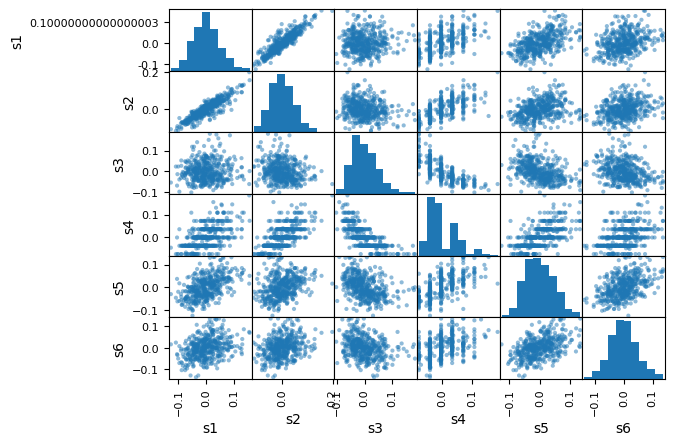

In [ ]:
def make_scatter_matrix(df):
    columns = ["s1", "s2", "s3", "s4", "s5", "s6"]
    pd.plotting.scatter_matrix(df[columns])
    return

make_scatter_matrix(df)

### Task 2: Figure Caption

[WRITE YOUR FIGURE CAPTION HERE]

### Task 3: The Train-Test Split

In [ ]:
def extract_data_from_df(df):
    feature_columns = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
    Y = df["Target"]
    X = df[feature_columns]

    return X, Y

X, Y = extract_data_from_df(df)
assert X.shape[0] == Y.shape[0], "X and Y should have the same number of samples."
print(f"The dataset has {X.shape[0]} samples and {X.shape[1]} features.")

The dataset has 442 samples and 10 features.


In [ ]:
def perform_train_test_split(X, Y):
    Xtrn, Xtst, Ytrn, Ytst = train_test_split(X, Y, train_size=0.50, random_state=1415)
    return Xtrn, Xtst, Ytrn, Ytst

Xtrn, Xtst, Ytrn, Ytst = perform_train_test_split(X, Y)
assert Xtrn.shape[1] == Xtst.shape[1], "Xtrn and Xtst should have the same number of columns."
assert Xtrn.shape[0] == Ytrn.shape[0], "Xtrn and Ytrn should have the same number of samples."
assert Xtst.shape[0] == Ytst.shape[0], "Xtst and Ytst should have the same number of samples."
print(f"The training set has {Xtrn.shape[0]} samples.")
print(f"The testing set has {Xtst.shape[0]} samples.")

The training set has 221 samples.
The testing set has 221 samples.


### Task 4: Linear Regression

In [ ]:
def perform_linear_regression(Xtrn, Ytrn):
    linreg = LinearRegression()
    linreg.fit(Xtrn, Ytrn)
    train_score = linreg.score(Xtrn, Ytrn)
    return linreg, train_score

linreg, train_score = perform_linear_regression(Xtrn, Ytrn)
train_score

0.5232052457340652

### Task 5: Model Performance

In [ ]:
def check_model_performance(linreg, Xtst, Ytst):
    test_score = linreg.score(Xtst, Ytst)
    return test_score

test_score = check_model_performance(linreg, Xtst, Ytst)
test_score

0.4848314530654446